# Diffusion priors for plasma tomography — tutorial

This notebook walks through the full reconstruction pipeline of the paper
*"Diffusion Priors for Plasma Tomography: Bayesian Data-Driven Methods Applied to SXR Reconstruction"* (Hamm, Haouchat, Theiler, Unser):

1. [Setup](#1.-Setup) — load the pretrained diffusion prior and the SXR forward model
2. [Sampling the learned prior](#2.-Sampling-the-learned-prior)
3. [Posterior sampling with DiffPIR](#3.-Posterior-sampling-with-DiffPIR) — synthetic phantom, uncertainty quantification
4. [Equilibrium-informed DiffRD](#4.-Equilibrium-informed-DiffRD)
5. [Experimental TCV data](#5.-Experimental-TCV-data) — shot 85270
6. [Training your own prior](#6.-Training-your-own-prior)

Everything needed is bundled in `data/` (≈8 MB). Runtime: a few minutes on a GPU; on CPU, reduce `NUM_SAMPLES` and `NUM_STEPS` below.

## 1. Setup

The reconstruction problem is the linear inverse problem $\mathbf{y} = \mathbf{T}\mathbf{x} + \boldsymbol{\varepsilon}$, where $\mathbf{x} \in \mathbb{R}^{120\times 40}$ is the emissivity profile on the poloidal cross-section of TCV, $\mathbf{T}$ is the geometry matrix of the diagnostic (here RADCAM's SXR: 100 lines of sight), and $\boldsymbol{\varepsilon}$ is Gaussian noise.

The prior $p(\mathbf{x})$ is a diffusion model trained once on physically realistic synthetic profiles; it is **agnostic to the diagnostic**, so the same checkpoint serves any forward model.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

import plasma_diffusion as pdiff

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# reduce these on CPU (e.g. 10 samples / 50 steps)
NUM_SAMPLES = 50
NUM_STEPS = 250

device: cuda


geometry matrix: 100 lines of sight x 4800 pixels


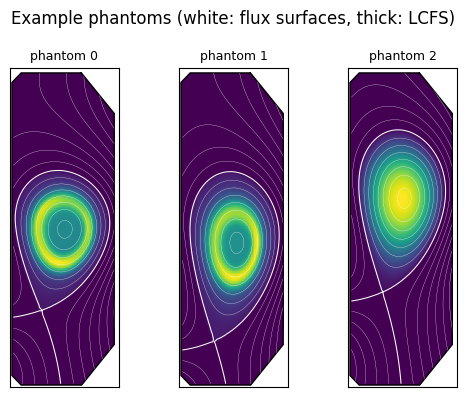

In [2]:
# pretrained diffusion prior (trained on synthetic SXR profiles) + DDPM schedule
model = pdiff.load_pretrained("data/prior_sxr.pth", device=device)
schedule = pdiff.build_schedule(num_train_steps=1000, device=device)

# SXR geometry matrix, normalized to unit maximum for conditioning
A_raw = np.load("data/geometry_sxr.npy")
A_max = float(A_raw.max())          # kept to rescale physical measurements later
A = A_raw / A_max
n_channels, n_pixels = A.shape
H, W = 120, 40
print(f"geometry matrix: {n_channels} lines of sight x {n_pixels} pixels")

# example phantoms (ground truth) and their magnetic equilibria
phantoms = np.load("data/phantoms_example.npy")   # (3, H, W)
psis = np.load("data/psi_example.npy")            # (3, H, W)

pdiff.show_samples(phantoms, contour_images=list(psis),
                   titles=[f"phantom {i}" for i in range(len(phantoms))],
                   title="Example phantoms (white: flux surfaces, thick: LCFS)");

## 2. Sampling the learned prior

Unconditional samples show what the model has learned about plasma emissivity: core-localized, flux-aligned structures with realistic shapes — no measurement involved.

Prior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

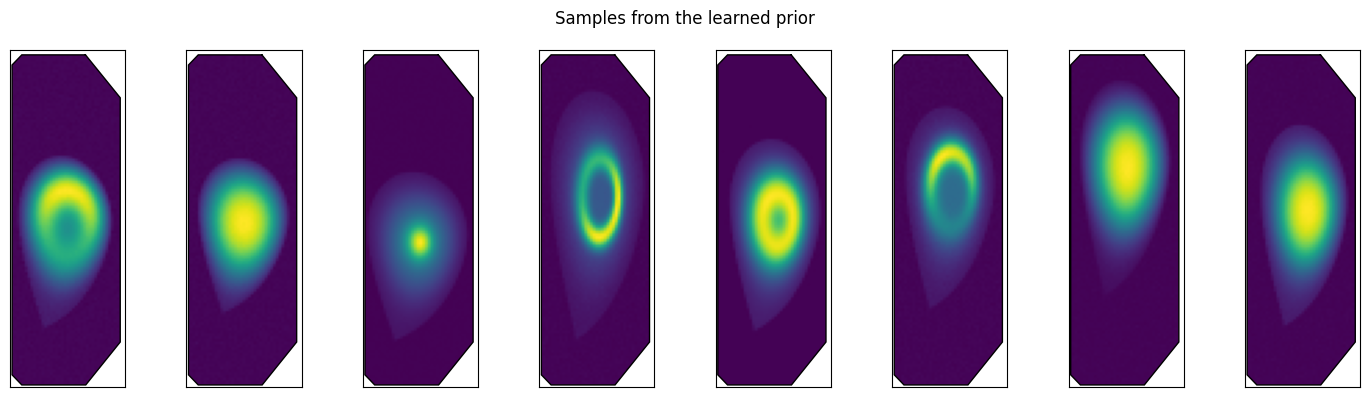

In [3]:
prior_samples, _ = pdiff.sample_prior(
    model, schedule,
    num_samples=8,
    num_inference_steps=NUM_STEPS,
    eta=0.0,          # deterministic DDIM
)
pdiff.show_samples(prior_samples, title="Samples from the learned prior");

## 3. Posterior sampling with DiffPIR

We now condition on noisy synthetic measurements of the first phantom. DiffPIR alternates a **prior step** (the network denoises the iterate) with a **likelihood step** (a proximal subproblem enforcing data fidelity, solved in closed form). Each run of the sampler yields one approximate posterior sample; the posterior mean $\boldsymbol{\mu}$ (our reconstruction) and pixel-wise std $\boldsymbol{\sigma}$ (our uncertainty map) are Monte-Carlo estimates over samples.

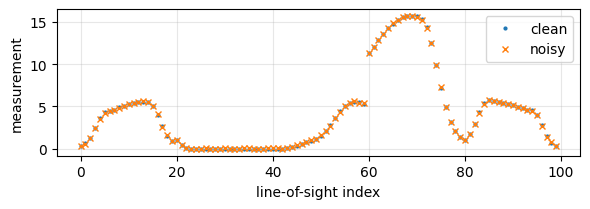

In [4]:
x_gt = phantoms[0]
psi = psis[0]
sigma_y = 0.05   # measurement noise std, in normalized units

rng = np.random.default_rng(SEED)
y_clean = A @ x_gt.ravel()
y = y_clean + sigma_y * rng.standard_normal(n_channels)

fig, ax = plt.subplots(figsize=(6, 2.2))
ax.plot(y_clean, ".", label="clean", ms=4)
ax.plot(y, "x", label="noisy", ms=4)
ax.set_xlabel("line-of-sight index"); ax.set_ylabel("measurement")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

In [5]:
posterior, residuals, _ = pdiff.sample_posterior_diffpir(
    model, schedule, A, y,
    num_samples=NUM_SAMPLES,
    num_inference_steps=NUM_STEPS,
    sigma_y=sigma_y,
    lambda_=100.0,    # DiffPIR regularization (paper value for SXR)
    zeta=0.8,         # stochasticity of the reverse update
)

post_mean = posterior.mean(dim=0)[0].cpu().numpy()
post_std = posterior.std(dim=0)[0].cpu().numpy()

data_range = float(x_gt.max() - x_gt.min())
print(f"PSNR(mean) = {psnr(x_gt, post_mean, data_range=data_range):.2f} dB | "
      f"SSIM(mean) = {ssim(x_gt, post_mean, data_range=data_range):.3f}")

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

PSNR(mean) = 43.65 dB | SSIM(mean) = 0.997


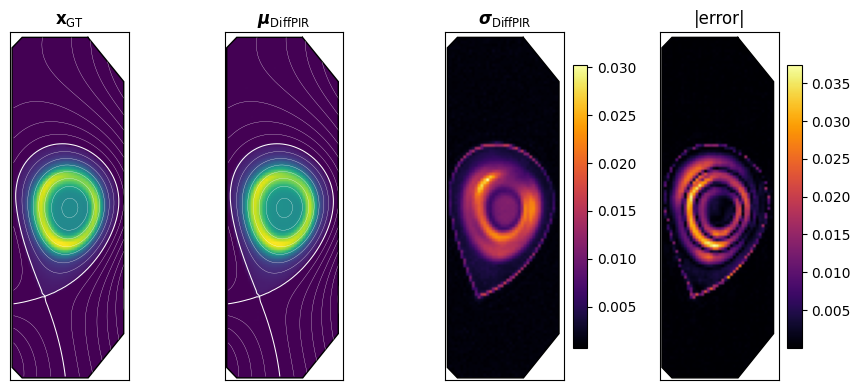

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(9, 4))
pdiff.plot_profile(x_gt, ax=axes[0], contour_image=psi)
axes[0].set_title(r"$\mathbf{x}_{\mathrm{GT}}$")
pdiff.plot_profile(post_mean, ax=axes[1], contour_image=psi)
axes[1].set_title(r"$\boldsymbol{\mu}_{\mathrm{DiffPIR}}$")
pdiff.plot_profile(post_std, ax=axes[2], cmap="inferno", colorbar=True)
axes[2].set_title(r"$\boldsymbol{\sigma}_{\mathrm{DiffPIR}}$")
pdiff.plot_profile(np.abs(post_mean - x_gt), ax=axes[3], cmap="inferno", colorbar=True)
axes[3].set_title("|error|")
plt.tight_layout()

Note how the uncertainty map correlates with the actual reconstruction error — the posterior spread is informative about *where* the reconstruction can be trusted, one of the key advantages over hand-crafted Gaussian priors (Sec. 4 of the paper).

## 4. Equilibrium-informed DiffRD

When the magnetic equilibrium is known, the proximal subproblem can be augmented with the anisotropic reaction-diffusion smoothness term $\lambda_{\mathrm{rd}}\,\bar\sigma_t\,\|\mathbf{L}\mathbf{x}\|^2$, which promotes smoothness **along flux surfaces** with a strength that decays along the reverse process (Algorithm 1 of the paper). This is most valuable for poorly-conditioned, single-camera diagnostics (Pilatus in the paper); here we demonstrate the mechanics on SXR.

The operator $\mathbf{L}$ for this equilibrium is precomputed in `data/rd_operator_example.npz`. To build one for a different equilibrium, use `pdiff.build_rd_operator(psi)` (requires the optional dependency `pyxu-diffops`).

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

PSNR(mean) = 34.68 dB | SSIM(mean) = 0.969


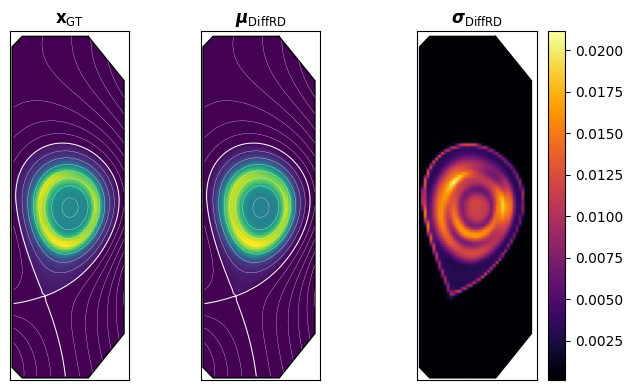

In [7]:
L, _ = pdiff.load_rd_operator("data/rd_operator_example.npz")

posterior_rd, _, _ = pdiff.sample_posterior_diffpir(
    model, schedule, A, y,
    num_samples=NUM_SAMPLES,
    num_inference_steps=NUM_STEPS,
    sigma_y=sigma_y,
    lambda_=100.0,
    zeta=0.8,
    rd_matrix=L,       # <- enables DiffRD
    lambda_rd=1e-4,    # paper values: 1e-5 - 1e-4 depending on noise level
)

rd_mean = posterior_rd.mean(dim=0)[0].cpu().numpy()
rd_std = posterior_rd.std(dim=0)[0].cpu().numpy()
print(f"PSNR(mean) = {psnr(x_gt, rd_mean, data_range=data_range):.2f} dB | "
      f"SSIM(mean) = {ssim(x_gt, rd_mean, data_range=data_range):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(7, 4))
pdiff.plot_profile(x_gt, ax=axes[0], contour_image=psi)
axes[0].set_title(r"$\mathbf{x}_{\mathrm{GT}}$")
pdiff.plot_profile(rd_mean, ax=axes[1], contour_image=psi)
axes[1].set_title(r"$\boldsymbol{\mu}_{\mathrm{DiffRD}}$")
pdiff.plot_profile(rd_std, ax=axes[2], cmap="inferno", colorbar=True)
axes[2].set_title(r"$\boldsymbol{\sigma}_{\mathrm{DiffRD}}$")
plt.tight_layout()

## 5. Experimental TCV data

Finally we reconstruct real SXR measurements from TCV shot 85270. Two preprocessing steps bring the data to the scale of the learned prior:

1. **Units** — raw detector signals are converted to line-integrated units and matched to the normalized geometry matrix (`build_measurement`);
2. **Amplitude normalization** — the amplitude scale $\alpha$ is estimated by projecting the measurement onto its closest (shape-wise) training measurement (`normalization_coefficient`); reconstructions are rescaled by $\alpha$ afterwards.

The noise level is estimated directly from the measurement vector. Note the equilibrium is **not used** by DiffPIR — the flux contours are overlaid only for validation.

In [8]:
import scipy.io as scio

shot = scio.loadmat("data/shot_85270.mat")["data"][0, 0]
times = shot["measurements_times"].flatten()
frame = 14
print(f"shot 85270, t = {times[frame]:.2f} s")

# equilibria interpolated onto the reconstruction grid (for validation plots)
psi_exp = pdiff.interpolate_equilibria(shot, nz=H, nr=W)

# measurement vector in normalized-geometry units, faulty channels removed
y_exp, good_channels = pdiff.build_measurement(shot, frame=frame, geometry_max=A_max)
A_good = A[good_channels]

# amplitude normalization towards the training distribution
y_train = np.load("data/y_train_sxr.npy")        # measurements of the training set
alpha = pdiff.normalization_coefficient(y_exp, y_train[:, good_channels])
y_exp_scaled = y_exp / alpha

# noise level estimated from the measurement itself
sigma_exp = pdiff.estimate_noise_std(y_exp_scaled)
print(f"{len(good_channels)} good channels | alpha = {alpha:.3e} | sigma = {sigma_exp:.4f}")

shot 85270, t = 0.90 s
99 good channels | alpha = 8.924e+09 | sigma = 0.0421


Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

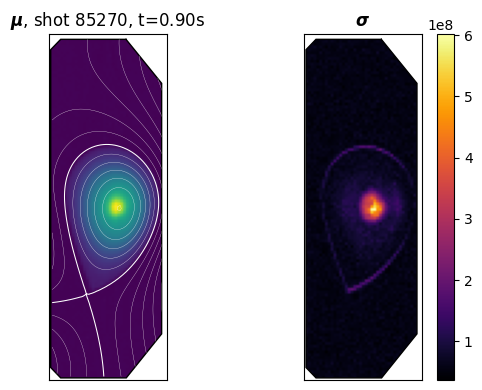

In [9]:
posterior_exp, _, _ = pdiff.sample_posterior_diffpir(
    model, schedule, A_good, y_exp_scaled,
    num_samples=NUM_SAMPLES,
    num_inference_steps=NUM_STEPS,
    sigma_y=sigma_exp,
    lambda_=100.0,
    zeta=0.8,
)

# back to physical amplitude
exp_mean = posterior_exp.mean(dim=0)[0].cpu().numpy() * alpha
exp_std = posterior_exp.std(dim=0)[0].cpu().numpy() * alpha

fig, axes = plt.subplots(1, 2, figsize=(5.5, 4))
pdiff.plot_profile(exp_mean, ax=axes[0], contour_image=psi_exp[frame])
axes[0].set_title(rf"$\boldsymbol{{\mu}}$, shot 85270, t={times[frame]:.2f}s")
pdiff.plot_profile(exp_std, ax=axes[1], cmap="inferno", colorbar=True)
axes[1].set_title(r"$\boldsymbol{\sigma}$")
plt.tight_layout()

The reconstruction is nicely aligned with the (overlaid, unused) flux surfaces — an independent consistency check between the diagnostic and the equilibrium reconstruction code (Sec. 4.3 of the paper).

## 6. Training your own prior

The prior was trained on ~10⁵ synthetic emissivity phantoms built from magnetic equilibria of TCV discharges. To train on your own profiles (a set of `.npy` files of shape `(120, 40)`, amplitude ~[0, 1]):

```bash
python -m plasma_diffusion.training --data-glob "path/to/profiles/*.npy" \
    --epochs 2000 --batch-size 512 --out checkpoints/
```

then load any checkpoint with `pdiff.load_pretrained("checkpoints/prior_epoch_1999.pth")`. Since the prior is decoupled from the reconstruction, the same checkpoint works for **any** diagnostic geometry — just pass a different matrix `A` to the samplers.